In [1]:
import torch.nn as nn
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model

import os
import dotenv
import pathlib
API_KEY, HF_TOKEN = dotenv.dotenv_values("secret.env").values()

# Log in to Hugging Face
from huggingface_hub import snapshot_download, login
login(token=HF_TOKEN)

del HF_TOKEN

with os.scandir("./models/qwen2.5") as it:
    local_folder = "./models/qwen2.5" # Change to preferred path
    model_id = "Qwen/Qwen2.5-1.5B"
    if not any(it):
        print("Downloading Qwen2.5-1.5B...")
        download_path = snapshot_download(
            repo_id=model_id,
            local_dir=local_folder,
            ignore_patterns=["*.msgpack", "*.h5", "*.ot", "rust_model.ot", "original/*", "README.md"],
            max_workers=4 # Downloads 4 files at a time
        )
        print(f"Download complete! Model saved locally at: {download_path}")
    else:
        print(f"Model {model_id} already downloaded.")

with os.scandir("./models/roberta-base") as it:
    local_folder = "./models/roberta-base" # Change to preferred path
    model_id = "roberta-base"
    if not any(it):
        print("Downloading roberta-base...")
        download_path = snapshot_download(
            repo_id=model_id,
            local_dir=local_folder,
            ignore_patterns=["*.msgpack", "*.h5", "*.ot", "rust_model.ot", "original/*", "*.flax", "README.md"],
            max_workers=4 # Downloads 4 files at a time
        )
        print(f"Download complete! Model saved locally at: {download_path}")
    else:
        print(f"Model {model_id} already downloaded.")


Model Qwen/Qwen2.5-1.5B already downloaded.
Model roberta-base already downloaded.


# Dataset Preprocessing

## 1. Automatic Annotation Generation using Gemini 2.5 Flash

In [2]:
import google.genai as genai
import json
import time
from pydantic import BaseModel, Field

dataset_dir = pathlib.Path("./dataset")
output_file = "cad_hierarchical_dataset.jsonl"

In [ ]:
client = genai.Client(api_key=API_KEY)

class CADAnnotation(BaseModel):
    level_1_category: str = Field(description="Functional Category (e.g., 'Hexagonal Bolt')")
    level_2_topology: str = Field(description="Topological Structure (e.g., 'A cylindrical shaft joined to a hexagonal head.')")
    level_3_parametric: str = Field(description="Parametric Specification (e.g., 'M8x1.25 standard hex bolt, shaft length 20mm')")
    citations: list[str] = Field(description="Exact string matches copied directly from the Raw Geometry Data.")

TEMPERATURE = 0.1

def generate_annotation(file_path):
    uploaded_file = None
    try:
        print(f"  -> Uploading {file_path.name} to Gemini API...")
        
        uploaded_file = client.files.upload(
            file=str(file_path), 
            config={'mime_type': 'text/plain'}
        )
        
        time.sleep(2)
        
        prompt = """
        You are an expert mechanical engineer. Read the attached raw CAD STEP file. 
        Analyze the Boundary Representation (B-Rep) geometry and extract the 3 levels of annotation.
        **IMPORTANT: MAKE NO MISTAKES. ENSURE THE B-REP ANALYSIS IS ACCURATE ACCORDING TO THE FILE CONTENTS.
        CRITICAL INSTRUCTIONS:
        - For Level 3: You MUST provide the overall bounding box dimensions (Length, Width, Height). If exact lengths are not explicitly stated, derive them by looking at the min/max coordinates in the CARTESIAN_POINT data. Do not just say "41 planar faces".
        - For Citations: Do not just dump 50 unreadable lines of "PLANE('', #123)". Only cite the specific CARTESIAN_POINT or CYLINDRICAL_SURFACE lines that prove the exact numerical measurements you wrote in Level 3.
        **
        """
        
        print(f"  -> Generating annotation...")
        
        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents=[prompt, uploaded_file],
            config=genai.types.GenerateContentConfig(
                response_mime_type="application/json",
                response_schema=CADAnnotation,
                temperature=0.1
            )
        )
        
        if response.parsed:
            print(f"Response: {response.parsed}")
            return response.parsed.model_dump()
        else:
            # Fallback 
            return json.loads(response.text)
        
    except Exception as e:
        print(f"  -> [!] API Error on {file_path.name}: {e}")
        return None
        
    finally:
        # Delete the file to save storage quota
        if uploaded_file:
            try:
                client.files.delete(name=uploaded_file.name)
            except Exception as e:
                print(f"  -> [!] Failed to delete {uploaded_file.name} from cloud: {e}")

step_files = list(dataset_dir.rglob("*.step"))
print(f"Found {len(step_files)} STEP files to process.")

# Set limit to 10 files for now
LIMIT = 10
l = 0
if not os.path.exists(output_file):
    with open(output_file, 'a') as f:
        for i, file_path in enumerate(step_files):
            if l >= LIMIT:
                break
            file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
            if file_size_mb > 2.5:
                print(f"  -> [!] Skipping {file_path.name}: File too large ({file_size_mb:.2f} MB)")
                continue
            l += 1
            print(f"[{l}/{LIMIT}] Processing {file_path.parent.name}/{file_path.name}")

            annotation = generate_annotation(file_path)
            
            if annotation:
                dataset_entry = {
                    "file_path": str(file_path),
                    "file_name": file_path.name,
                    "hierarchical_target": f"[L1] {annotation['level_1_category']} [L2] {annotation['level_2_topology']} [L3] {annotation['level_3_parametric']}",
                    "citations": annotation['citations']
                }
                
                f.write(json.dumps(dataset_entry) + "\n")
                f.flush()
                
            # Respect rate limits
            time.sleep(4)

## 2. Canonical Graph Normalization

In [4]:
import numpy as np
from OCC.Core.STEPControl import STEPControl_Reader
from OCC.Core.TopExp import TopExp_Explorer
from OCC.Core.TopAbs import TopAbs_FACE, TopAbs_EDGE, TopAbs_VERTEX
from OCC.Core.TopoDS import topods
from OCC.Core.BRepAdaptor import BRepAdaptor_Surface, BRepAdaptor_Curve
from OCC.Core.BRep import BRep_Tool
from OCC.Core.GeomAbs import (
    GeomAbs_Plane, GeomAbs_Cylinder, GeomAbs_Cone, GeomAbs_Sphere, 
    GeomAbs_Torus, GeomAbs_BSplineSurface, GeomAbs_SurfaceOfExtrusion,
    GeomAbs_SurfaceOfRevolution, GeomAbs_Line, GeomAbs_Circle, 
    GeomAbs_Ellipse, GeomAbs_Parabola, GeomAbs_Hyperbola, GeomAbs_BSplineCurve
)
from OCC.Core.BRepGProp import brepgprop
from OCC.Core.GProp import GProp_GProps
from OCC.Core.BRepBuilderAPI import BRepBuilderAPI_Transform
from OCC.Core.gp import gp_Trsf, gp_Vec

import networkx as nx
from networkx.algorithms import isomorphism

import math

def canonical_normalize_shape(shape):
    """
    Translates the shape's centroid to (0,0,0) and rotates it 
    using PCA so the principal axis of variance aligns with the Z-axis.
    """
    # 1. Extract all vertices to build a mathematical Point Cloud
    vertices = []
    explorer = TopExp_Explorer(shape, TopAbs_VERTEX)
    while explorer.More():
        v = topods.Vertex(explorer.Current())
        pnt = BRep_Tool.Pnt(v)
        vertices.append([pnt.X(), pnt.Y(), pnt.Z()])
        explorer.Next()
        
    # Fallback for extremely simple shapes (e.g., a perfect sphere has 1 vertex in B-Rep)
    if len(vertices) < 3:
        return shape 
        
    P = np.array(vertices)
    
    # 2. Centroid Subtraction (Translational Invariance)
    mu = np.mean(P, axis=0)
    P_centered = P - mu
    
    # 3. PCA Covariance & Eigen Decomposition (Rotational Invariance)
    covariance_matrix = np.cov(P_centered, rowvar=False)
    _, eigenvectors = np.linalg.eigh(covariance_matrix)
    
    # np.linalg.eigh returns eigenvalues in ASCENDING order.
    # By keeping [0, 1, 2], the longest axis (index 2) automatically aligns to the Z-axis.
    
    # Ensure a right-handed coordinate system (Determinant must be strictly positive 1)
    if np.linalg.det(eigenvectors) < 0:
        eigenvectors[:, 0] = -eigenvectors[:, 0]
        
    # The eigenvectors represent the rotation FROM the canonical frame TO the current frame.
    # Use the inverse (transpose) to rotate the object TO the canonical frame.
    R = eigenvectors.T 
    
    # 4. Build the OpenCASCADE Transformation Matrices
    # Translation: Move the object by -mu
    trsf_translate = gp_Trsf()
    trsf_translate.SetTranslation(gp_Vec(-mu[0], -mu[1], -mu[2]))
    
    # Rotation: Apply the transposed eigenvector matrix
    trsf_rotate = gp_Trsf()
    trsf_rotate.SetValues(
        R[0,0], R[0,1], R[0,2], 0.0,
        R[1,0], R[1,1], R[1,2], 0.0,
        R[2,0], R[2,1], R[2,2], 0.0
    )
    
    # Combine transformations: Translate first, then Rotate
    final_trsf = trsf_rotate.Multiplied(trsf_translate)
    
    # 5. Get the transformed shape
    transformer = BRepBuilderAPI_Transform(shape, final_trsf, True)
    normalized_shape = transformer.Shape()
    
    return normalized_shape

## 3. Topological Linearization

In [5]:
def get_surface_token(geom_type):
    """Maps OpenCASCADE surfaces to exact ISO 10303 tokens."""
    mapping = {
        GeomAbs_Plane: "<PLANE>",
        GeomAbs_Cylinder: "<CYLINDRICAL_SURFACE>",
        GeomAbs_Cone: "<CONICAL_SURFACE>",
        GeomAbs_Sphere: "<SPHERICAL_SURFACE>",
        GeomAbs_Torus: "<TOROIDAL_SURFACE>",
        GeomAbs_BSplineSurface: "<B_SPLINE_SURFACE_WITH_KNOTS>",
        GeomAbs_SurfaceOfExtrusion: "<SURFACE_OF_LINEAR_EXTRUSION>",
        GeomAbs_SurfaceOfRevolution: "<SURFACE_OF_REVOLUTION>"
    }
    return mapping.get(geom_type, "<ADVANCED_FACE>")

def get_curve_token(geom_type):
    """Maps OpenCASCADE curves to exact ISO 10303 tokens."""
    mapping = {
        GeomAbs_Line: "<LINE>",
        GeomAbs_Circle: "<CIRCLE>",
        GeomAbs_Ellipse: "<ELLIPSE>",
        GeomAbs_Parabola: "<PARABOLA>",
        GeomAbs_Hyperbola: "<HYPERBOLA>",
        GeomAbs_BSplineCurve: "<B_SPLINE_CURVE_WITH_KNOTS>"
    }
    return mapping.get(geom_type, "<EDGE_CURVE>")

def calculate_geometric_invariants(occ_shape):
    """Calculates Area/Length and Centroid (X,Y,Z) for the sorting key."""
    props = GProp_GProps()
    shape_type = occ_shape.ShapeType()
    
    magnitude: float = 0.0
    centroid: tuple[float, float, float] = (.0, .0, .0)

    if shape_type == TopAbs_FACE:
        brepgprop.SurfaceProperties(occ_shape, props)
        magnitude = props.Mass() # Return surface area for faces
        com = props.CentreOfMass()
        centroid = (com.X(), com.Y(), com.Z())
    elif shape_type == TopAbs_EDGE:
        brepgprop.LinearProperties(occ_shape, props)
        magnitude = props.Mass() # Return curve length for edges
        com = props.CentreOfMass()
        centroid = (com.X(), com.Y(), com.Z())
    elif shape_type == TopAbs_VERTEX:
        # Vertices have 0 magnitude
        from OCC.Core.BRep import BRep_Tool
        pnt = BRep_Tool.Pnt(occ_shape)
        centroid = (pnt.X(), pnt.Y(), pnt.Z())
        
    
    return magnitude, centroid

def get_sorting_key(graph, node):
    data = graph.nodes[node]
    
    # Use pre-computed raw math to sort the graph
    math_vec = data.get('macro_math', data.get('raw_math', np.zeros(128, dtype=np.float32)))
    centroid = math_vec[0:3]
    magnitude = math_vec[6]
    
    dist_to_origin = math.sqrt(sum(c**2 for c in centroid))
    degree = graph.degree(node)
    
    return (-magnitude, dist_to_origin, -degree, -centroid[2], -centroid[1], -centroid[0])

## Extract Geometric Vectors (Stream B)

In [6]:
def extract_stream_b_vector(occ_shape):
    """Calculates the 128-dim Stream B vector for raw primitives."""
    v = np.zeros(128, dtype=np.float32)
    if occ_shape is None: 
        return v
    
    magnitude, centroid = calculate_geometric_invariants(occ_shape)
    v[0:3] = centroid
    v[6] = magnitude
    
    try:
        if occ_shape.ShapeType() == TopAbs_FACE:
            surf = BRepAdaptor_Surface(topods.Face(occ_shape), True)
            if surf.GetType() == GeomAbs_Cylinder:
                v[7] = surf.Cylinder().Radius()
                axis = surf.Cylinder().Axis().Direction()
                v[3:6] = [axis.X(), axis.Y(), axis.Z()]
            elif surf.GetType() == GeomAbs_Cone:
                v[7] = surf.Cone().RefRadius()
                v[8] = surf.Cone().SemiAngle()
        elif occ_shape.ShapeType() == TopAbs_EDGE:
            curve = BRepAdaptor_Curve(topods.Edge(occ_shape))
            if curve.GetType() == GeomAbs_Circle:
                v[7] = curve.Circle().Radius()
    except: pass
    return v

def precompute_geometric_vectors(brep_graph):
    """Pass 0: Calculates and stores the 128-dim vector for every raw node."""
    for node, data in brep_graph.nodes(data=True):
        occ_shape = data.get('occ_shape')
        # entity_type = data.get('entity_type')
        
        # We reuse the extractor function we already wrote
        vector = extract_stream_b_vector(occ_shape)
        
        # Store it directly in the NetworkX node attributes
        brep_graph.nodes[node]['raw_math'] = vector
        
    return brep_graph

## Semantic Macro Compression

In [7]:
def node_match(n1, n2):
    return n1.get('entity_type') == n2.get('entity_type')

def compress_hole_macros(brep_graph):
    hole_template = nx.DiGraph()
    hole_template.add_node("cyl", entity_type="<CYLINDRICAL_SURFACE>")
    hole_template.add_node("c1", entity_type="<CIRCLE>")
    hole_template.add_node("c2", entity_type="<CIRCLE>")
    hole_template.add_node("p1", entity_type="<PLANE>")
    hole_template.add_node("p2", entity_type="<PLANE>")
    
    # The cylinder and planes share the circular edges
    hole_template.add_edges_from([("cyl", "c1"), ("cyl", "c2"), ("p1", "c1"), ("p2", "c2")])

    matcher = isomorphism.DiGraphMatcher(brep_graph, hole_template, node_match=node_match)
    
    macro_id_counter = 1
    for match in list(matcher.subgraph_isomorphisms_iter()):
        nodes_in_match = list(match.keys())
        # Check if another macro already consumed these nodes
        if not all(n in brep_graph for n in nodes_in_match):
            continue
        
        inv_match = {v: k for k, v in match.items()}
        cyl_math = np.copy(brep_graph.nodes[inv_match["cyl"]]['raw_math'])
        p1_math = brep_graph.nodes[inv_match["p1"]]['raw_math']
        p2_math = brep_graph.nodes[inv_match["p2"]]['raw_math']
        
        # Euclidean distance between the two plane centroids = Hole Depth
        depth = np.linalg.norm(p1_math[0:3] - p2_math[0:3])
        cyl_math[9] = depth # Store depth in slot 9

        # Assign occ_shape=None so the get_sorting_key function doesn't crash 
        # when trying to calculate the surface area of a macro node.
        new_macro_id = f"MACRO_HOLE_{macro_id_counter}"
        brep_graph.add_node(new_macro_id, entity_type="<THROUGH_HOLE>", occ_shape=None, macro_math=cyl_math)
        macro_id_counter += 1
        
        # Recalculate surrounding topology to the new macro node
        for old_node in nodes_in_match:
            for predecessor in list(brep_graph.predecessors(old_node)):
                if predecessor not in nodes_in_match:
                    brep_graph.add_edge(predecessor, new_macro_id)
            for successor in list(brep_graph.successors(old_node)):
                if successor not in nodes_in_match:
                    brep_graph.add_edge(new_macro_id, successor)
                    
        brep_graph.remove_nodes_from(nodes_in_match)
    
    if macro_id_counter > 1:
        print(f"  -> Compressed {macro_id_counter - 1} <THROUGH_HOLE> macros.")
    return brep_graph

def compress_chamfer_macros(brep_graph):
    chamfer_template = nx.DiGraph()
    chamfer_template.add_node("cone", entity_type="<CONICAL_SURFACE>")
    chamfer_template.add_node("c1", entity_type="<CIRCLE>")
    chamfer_template.add_node("c2", entity_type="<CIRCLE>")
    chamfer_template.add_node("p1", entity_type="<PLANE>")
    chamfer_template.add_node("p2", entity_type="<PLANE>")
    
    # Topology: Cone and Planes share the circular edges
    chamfer_template.add_edges_from([("cone", "c1"), ("cone", "c2"), ("p1", "c1"), ("p2", "c2")])

    matcher = isomorphism.DiGraphMatcher(brep_graph, chamfer_template, node_match=node_match)
    
    macro_id_counter = 1
    for match in list(matcher.subgraph_isomorphisms_iter()):
        nodes_in_match = list(match.keys())
        # Check if another macro already consumed these nodes
        if not all(n in brep_graph for n in nodes_in_match):
            continue

        inv_match = {v: k for k, v in match.items()}
        chamfer_math = np.copy(brep_graph.nodes[inv_match["cone"]]['raw_math'])
        
        # Calculate the chamfer width (distance between plane centroids)
        p1_math = brep_graph.nodes[inv_match["p1"]]['raw_math']
        p2_math = brep_graph.nodes[inv_match["p2"]]['raw_math']
        chamfer_math[9] = np.linalg.norm(p1_math[0:3] - p2_math[0:3])

        # Assign occ_shape=None so the get_sorting_key function doesn't crash 
        # when trying to calculate the surface area of a macro node.
        new_macro_id = f"MACRO_CHAMFER_{macro_id_counter}"
        brep_graph.add_node(new_macro_id, entity_type="<CHAMFER_EDGE>", occ_shape=None, macro_math=chamfer_math)
        macro_id_counter += 1
        
        # Recalculate surrounding topology to the new macro node
        for old_node in nodes_in_match:
            for predecessor in list(brep_graph.predecessors(old_node)):
                if predecessor not in nodes_in_match:
                    brep_graph.add_edge(predecessor, new_macro_id)
            for successor in list(brep_graph.successors(old_node)):
                if successor not in nodes_in_match:
                    brep_graph.add_edge(new_macro_id, successor)
                    
        brep_graph.remove_nodes_from(nodes_in_match)
    if macro_id_counter > 1:
        print(f"  -> Compressed {macro_id_counter - 1} <CHAMFER_EDGE> macros.")
    return brep_graph

def compress_fillet_macros(brep_graph):
    fillet_template = nx.DiGraph()
    fillet_template.add_node("bsurf1", entity_type="<B_SPLINE_SURFACE_WITH_KNOTS>")
    fillet_template.add_node("bsurf2", entity_type="<B_SPLINE_SURFACE_WITH_KNOTS>")
    # The shared boundary edge (often a B-Spline curve)
    fillet_template.add_node("edge", entity_type="<B_SPLINE_CURVE_WITH_KNOTS>")
    
    # Topology: Both surfaces point to the exact same shared edge
    fillet_template.add_edges_from([("bsurf1", "edge"), ("bsurf2", "edge")])

    matcher = isomorphism.DiGraphMatcher(brep_graph, fillet_template, node_match=node_match)
    
    macro_id_counter = 1
    for match in list(matcher.subgraph_isomorphisms_iter()):
        nodes_in_match = list(match.keys())
        # Check if another macro already consumed these nodes
        if not all(n in brep_graph for n in nodes_in_match):
            continue
        
        inv_match = {v: k for k, v in match.items()}
        fillet_math = np.copy(brep_graph.nodes[inv_match["edge"]]['raw_math'])
        # Assign occ_shape=None so the get_sorting_key function doesn't crash 
        # when trying to calculate the surface area of a macro node.
        new_macro_id = f"MACRO_FILLET_{macro_id_counter}"
        brep_graph.add_node(new_macro_id, entity_type="<FILLET_CHAIN>", occ_shape=None, macro_math=fillet_math)
        macro_id_counter += 1
        
        # Recalculate surrounding topology to the new macro node
        for old_node in nodes_in_match:
            for predecessor in list(brep_graph.predecessors(old_node)):
                if predecessor not in nodes_in_match:
                    brep_graph.add_edge(predecessor, new_macro_id)
            for successor in list(brep_graph.successors(old_node)):
                if successor not in nodes_in_match:
                    brep_graph.add_edge(new_macro_id, successor)
                    
        brep_graph.remove_nodes_from(nodes_in_match)
        
    if macro_id_counter > 1:
        print(f"  -> Compressed {macro_id_counter - 1} <FILLET_CHAIN> macros.")
    return brep_graph

def compress_cylinder_macros(brep_graph):
    cylinder_template = nx.DiGraph()
    cylinder_template.add_node("cyl", entity_type="<CYLINDRICAL_SURFACE>")
    cylinder_template.add_node("c1", entity_type="<CIRCLE>")
    cylinder_template.add_node("c2", entity_type="<CIRCLE>")
    
    cylinder_template.add_edge("cyl", "c1")
    cylinder_template.add_edge("cyl", "c2")

    matcher = isomorphism.DiGraphMatcher(brep_graph, cylinder_template, node_match=node_match)
    subgraphs_to_collapse = list(matcher.subgraph_isomorphisms_iter())
    macro_id_counter = 1

    for match in subgraphs_to_collapse:
        nodes_in_match = list(match.keys())
        # Check if another macro already consumed these nodes
        if not all(n in brep_graph for n in nodes_in_match):
            continue
        
        inv_match = {v: k for k, v in match.items()}
        cyl_math = np.copy(brep_graph.nodes[inv_match["cyl"]]['raw_math'])
            
        # Assign occ_shape=None so the get_sorting_key function doesn't crash 
        # when trying to calculate the surface area of a macro node.
        new_macro_id = f"MACRO_CYL_{macro_id_counter}"
        brep_graph.add_node(new_macro_id, entity_type="<CYLINDER_PRIMITIVE>", occ_shape=None, macro_math=cyl_math)
        macro_id_counter += 1
        
        # Recalculate surrounding topology to the new macro node
        for old_node in nodes_in_match:
            for predecessor in list(brep_graph.predecessors(old_node)):
                if predecessor not in nodes_in_match:
                    brep_graph.add_edge(predecessor, new_macro_id)
            for successor in list(brep_graph.successors(old_node)):
                if successor not in nodes_in_match:
                    brep_graph.add_edge(new_macro_id, successor)
                    
        brep_graph.remove_nodes_from(nodes_in_match)
        
    if macro_id_counter > 1:
        print(f"  -> Compressed {macro_id_counter - 1} <CYLINDER_PRIMITIVE> macros.")
        
    return brep_graph

def compress_sphere_macros(brep_graph):
    sphere_template = nx.DiGraph()
    sphere_template.add_node("sph", entity_type="<SPHERICAL_SURFACE>")
    sphere_template.add_node("c1", entity_type="<CIRCLE>")
    sphere_template.add_edge("sph", "c1")

    matcher = isomorphism.DiGraphMatcher(brep_graph, sphere_template, 
                                         node_match=node_match)
    
    macro_id_counter = 1
    for match in list(matcher.subgraph_isomorphisms_iter()):
        nodes_in_match = list(match.keys())
        # Check if another macro already consumed these nodes
        if not all(n in brep_graph for n in nodes_in_match): 
            continue
        
        inv_match = {v: k for k, v in match.items()}
        sphere_math = np.copy(brep_graph.nodes[inv_match["sph"]]['raw_math'])
        
        # Assign occ_shape=None so the get_sorting_key function doesn't crash 
        # when trying to calculate the surface area of a macro node.
        new_macro_id = f"MACRO_SPH_{macro_id_counter}"
        brep_graph.add_node(new_macro_id, entity_type="<SPHERE_PRIMITIVE>", occ_shape=None, macro_math=sphere_math)
        macro_id_counter += 1
        
        # Recalculate surrounding topology to the new macro node
        for old_node in nodes_in_match:
            for p in list(brep_graph.predecessors(old_node)):
                if p not in nodes_in_match: brep_graph.add_edge(p, new_macro_id)
            for s in list(brep_graph.successors(old_node)):
                if s not in nodes_in_match: brep_graph.add_edge(new_macro_id, s)
                    
        brep_graph.remove_nodes_from(nodes_in_match)
    
    if macro_id_counter > 1:
        print(f"  -> Compressed {macro_id_counter - 1} <SPHERE_PRIMITIVE> macros.")

    return brep_graph

def compress_planar_macros(brep_graph):
    pad_template = nx.DiGraph()
    pad_template.add_node("plane", entity_type="<PLANE>")
    pad_template.add_node("loop", entity_type="<EDGE_LOOP>")
    pad_template.add_edge("plane", "loop")

    matcher = isomorphism.DiGraphMatcher(brep_graph, pad_template, 
                                         node_match=lambda n1, n2: n1.get('entity_type') == n2.get('entity_type'))
    
    macro_id_counter = 1
    for match in list(matcher.subgraph_isomorphisms_iter()):
        nodes_in_match = list(match.keys())
        # Check if another macro already consumed these nodes
        if not all(n in brep_graph for n in nodes_in_match): continue
        
        # Assign occ_shape=None so the get_sorting_key function doesn't crash 
        # when trying to calculate the surface area of a macro node.
        new_macro_id = f"MACRO_PAD_{macro_id_counter}"
        inv_match = {v: k for k, v in match.items()}
        brep_graph.add_node(new_macro_id, entity_type="<PLANAR_PAD>", occ_shape=None, pad_math=np.copy(brep_graph.nodes[inv_match["plane"]]['raw_math']))
        macro_id_counter += 1
        
        # Recalculate surrounding topology to the new macro node
        for old_node in nodes_in_match:
            for p in list(brep_graph.predecessors(old_node)):
                if p not in nodes_in_match: brep_graph.add_edge(p, new_macro_id)
            for s in list(brep_graph.successors(old_node)):
                if s not in nodes_in_match: brep_graph.add_edge(new_macro_id, s)
                    
        brep_graph.remove_nodes_from(nodes_in_match)

    if macro_id_counter > 1:
        print(f"  -> Compressed {macro_id_counter - 1} <PLANAR_PAD> macros.")
    return brep_graph

def compress_macros(compressed_graph):
    # Compress based on complexity / isolation of the macro token

    # 1. Complex tokens
    compressed_graph = compress_hole_macros(compressed_graph)
    print(f"HOLE-Compressed Graph built with {len(compressed_graph.nodes)} nodes and {len(compressed_graph.edges)} edges.")
    compressed_graph = compress_chamfer_macros(compressed_graph)
    print(f"CHAMFER-Compressed Graph built with {len(compressed_graph.nodes)} nodes and {len(compressed_graph.edges)} edges.")
    compressed_graph = compress_fillet_macros(compressed_graph)
    print(f"FILLET-Compressed Graph built with {len(compressed_graph.nodes)} nodes and {len(compressed_graph.edges)} edges.")

    # 2. Isolated tokens
    compressed_graph = compress_cylinder_macros(compressed_graph)
    print(f"CYLINDER-Compressed Graph built with {len(compressed_graph.nodes)} nodes and {len(compressed_graph.edges)} edges.")
    compressed_graph = compress_sphere_macros(compressed_graph)
    print(f"SPHERE-Compressed Graph built with {len(compressed_graph.nodes)} nodes and {len(compressed_graph.edges)} edges.")
    
    # 3. Base features
    compressed_graph = compress_planar_macros(compressed_graph)
    print(f"PLANAR-Compressed Graph built with {len(compressed_graph.nodes)} nodes and {len(compressed_graph.edges)} edges.")

    return compressed_graph

In [8]:
def extract_dual_stream(graph):
    visited = set()
    stream_a_tokens = ["<GEO_START>"]
    stream_b_vectors = [np.zeros(128, dtype=np.float32).tolist()] 
    
    root_nodes = [n for n, d in graph.in_degree() if d == 0]
    root_nodes.sort(key=lambda n: get_sorting_key(graph, n))
    
    def canonical_dfs(node):
        if node in visited: return
        visited.add(node)
        
        data = graph.nodes[node]
        stream_a_tokens.append(data['entity_type'])
        
        # Dual Stream logic: Prefer synthesized macro math, fallback to raw math
        vector = data.get('macro_math', data.get('raw_math', np.zeros(128, dtype=np.float32)))
        stream_b_vectors.append(vector.tolist()) # Convert to list for JSON serialization
        
        children = list(graph.successors(node))
        children.sort(key=lambda c: get_sorting_key(graph, c))
        for child in children: canonical_dfs(child)

    for root in root_nodes: canonical_dfs(root)
        
    stream_a_tokens.append("<GEO_END>")
    stream_b_vectors.append(np.zeros(128, dtype=np.float32).tolist())
    
    return stream_a_tokens, stream_b_vectors

## Extract Geometric Vectors (Stream B)

In [9]:
def parse_step_to_graph(filepath):
    """Parses a STEP file into a base NetworkX DiGraph."""
    reader = STEPControl_Reader()
    status = reader.ReadFile(str(filepath))
    
    if status != 1:
        print(f"Error reading {filepath}")
        return None
        
    reader.TransferRoots()

    shape = canonical_normalize_shape(reader.OneShape())
    
    brep_graph = nx.DiGraph()
    node_counter = 1
    edge_map = {} # Tracks shared edges to prevent duplication
    vertex_map = {} # Tracks shared vertices
    
    # Traverse all Faces
    face_explorer = TopExp_Explorer(shape, TopAbs_FACE)
    while face_explorer.More():
        face = topods.Face(face_explorer.Current())
        
        # 1. Map Surface Geometry
        surf_adaptor = BRepAdaptor_Surface(face)
        surf_token = get_surface_token(surf_adaptor.GetType())
        
        face_node = f"N_{node_counter}"
        # We store the OCC face object so we can extract math later
        brep_graph.add_node(face_node, entity_type=surf_token, occ_shape=face, raw_math=extract_stream_b_vector(face))
        node_counter += 1
        
        # Traverse Edges bounding this Face
        edge_explorer = TopExp_Explorer(face, TopAbs_EDGE)
        while edge_explorer.More():
            edge = topods.Edge(edge_explorer.Current())
            edge_hash = hash(edge)
            
            if edge_hash not in edge_map:
                # 2. Map Curve Geometry
                curve_adaptor = BRepAdaptor_Curve(edge)
                curve_token = get_curve_token(curve_adaptor.GetType())
                
                edge_node = f"N_{node_counter}"
                brep_graph.add_node(edge_node, entity_type=curve_token, occ_shape=edge)
                edge_map[edge_hash] = edge_node
                node_counter += 1
            else:
                edge_node = edge_map[edge_hash]
                
            # Connect Face to Edge
            brep_graph.add_edge(face_node, edge_node)
            
            # Traverse Vertices bounding this Edge
            vertex_explorer = TopExp_Explorer(edge, TopAbs_VERTEX)
            while vertex_explorer.More():
                vertex = topods.Vertex(vertex_explorer.Current())
                vertex_hash = hash(vertex)
                
                if vertex_hash not in vertex_map:
                    # 3. Map Vertex Geometry
                    vert_node = f"N_{node_counter}"
                    brep_graph.add_node(vert_node, entity_type="<VERTEX_POINT>", occ_shape=vertex)
                    vertex_map[vertex_hash] = vert_node
                    node_counter += 1
                else:
                    vert_node = vertex_map[vertex_hash]
                    
                # Connect Edge to Vertex
                brep_graph.add_edge(edge_node, vert_node)
                vertex_explorer.Next()
                
            edge_explorer.Next()
        face_explorer.Next()
        
    return brep_graph

In [10]:
annotated_files = []
with open(output_file, "r") as f:
    for i, line in enumerate(f):
        line = line.strip()
        if line:
            try:
                obj = json.loads(line)
                file_path = obj["file_path"]
                graph = parse_step_to_graph(file_path)
                print(f"Base Graph built with {len(graph.nodes)} nodes and {len(graph.edges)} edges.")
                
                graph = precompute_geometric_vectors(graph)
                # Execute it on the graph parsed in the previous step
                compressed_graph = compress_macros(graph)
                print(f"CYLINDER-Compressed Graph built with {len(compressed_graph.nodes)} nodes and {len(compressed_graph.edges)} edges.")
                token_stream, vector_stream = extract_dual_stream(compressed_graph)
                
                # Print the final sequence as a single string
                print("Token stream: ")
                print(" ".join(token_stream))
                print(f"Length: {len(token_stream)}")

                obj["token_stream"] = token_stream
                obj["vector_stream"] = vector_stream
                annotated_files.append(obj)

                print()
            except json.JSONDecodeError as e:
                print(f"Error decoding JSON on line {i}: {e}")
                continue

Base Graph built with 122 nodes and 203 edges.
HOLE-Compressed Graph built with 122 nodes and 203 edges.
  -> Compressed 1 <CHAMFER_EDGE> macros.
CHAMFER-Compressed Graph built with 118 nodes and 199 edges.
FILLET-Compressed Graph built with 118 nodes and 199 edges.
CYLINDER-Compressed Graph built with 118 nodes and 199 edges.
  -> Compressed 7 <SPHERE_PRIMITIVE> macros.
SPHERE-Compressed Graph built with 111 nodes and 192 edges.
PLANAR-Compressed Graph built with 111 nodes and 192 edges.
CYLINDER-Compressed Graph built with 111 nodes and 192 edges.
Token stream: 
<GEO_START> <CHAMFER_EDGE> <B_SPLINE_CURVE_WITH_KNOTS> <VERTEX_POINT> <VERTEX_POINT> <CONICAL_SURFACE> <CIRCLE> <VERTEX_POINT> <VERTEX_POINT> <LINE> <VERTEX_POINT> <LINE> <VERTEX_POINT> <CIRCLE> <CONICAL_SURFACE> <CIRCLE> <VERTEX_POINT> <VERTEX_POINT> <LINE> <VERTEX_POINT> <LINE> <VERTEX_POINT> <CIRCLE> <B_SPLINE_SURFACE_WITH_KNOTS> <CIRCLE> <VERTEX_POINT> <VERTEX_POINT> <CIRCLE> <CIRCLE> <B_SPLINE_SURFACE_WITH_KNOTS> <CIRCLE

In [ ]:
with open("annotated_dataset.jsonl", "a") as f:
    f.write("\n".join([json.dumps(dataset_entry) for dataset_entry in annotated_files]))

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Base model: GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)
Added 41 new tokens. New vocab size: 5029

Epoch 1/20 [Train]:   0%|          | 0/18 [00:00<?, ?it/s]

i: 0


Epoch 1/20 [Train]:   6%|▌         | 1/18 [00:01<00:31,  1.87s/it, loss=13.4183]

...

i: 16


Epoch 20/20 [Train]:  94%|█████████▍| 17/18 [00:33<00:01,  1.94s/it, loss=12.5335]

i: 17


Epoch 20/20 [Train]: 100%|██████████| 18/18 [00:35<00:00,  1.95s/it, loss=12.5940]


Running validation metrics on 20 samples...
input_ids: tensor([[50257, 50292, 50280,  ..., 50297, 50297, 50297]], device='cuda:0')
anno_idx: tensor([88], device='cuda:0')
prompt_len: 89
prompt_geom_vectors: tensor([[[  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
         [ -0.1467,  -1.3407,   1.7088,  ...,   0.0000,   0.0000,   0.0000],
         [ -0.1594, -12.7050,   0.4849,  ...,   0.0000,   0.0000,   0.0000],
         ...,
         [ -0.7231,   5.1891,   9.8618,  ...,   0.0000,   0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000],
         [  0.0000,   0.0000,   0.0000,  ...,   0.0000,   0.0000,   0.0000]]],
       device='cuda:0')
prompt_ids: tensor([[50257, 50292, 50280, 50260, 50284, 50260, 50260, 50292, 50280, 50260,
         50260, 50280, 50260, 50260, 50284, 50260, 50260, 50280, 50280, 50292,
         50280, 50260, 50260, 50280, 50260, 50260, 50284, 50260, 50260, 50280,
         50280, 50270, 50280, 50260, 50274

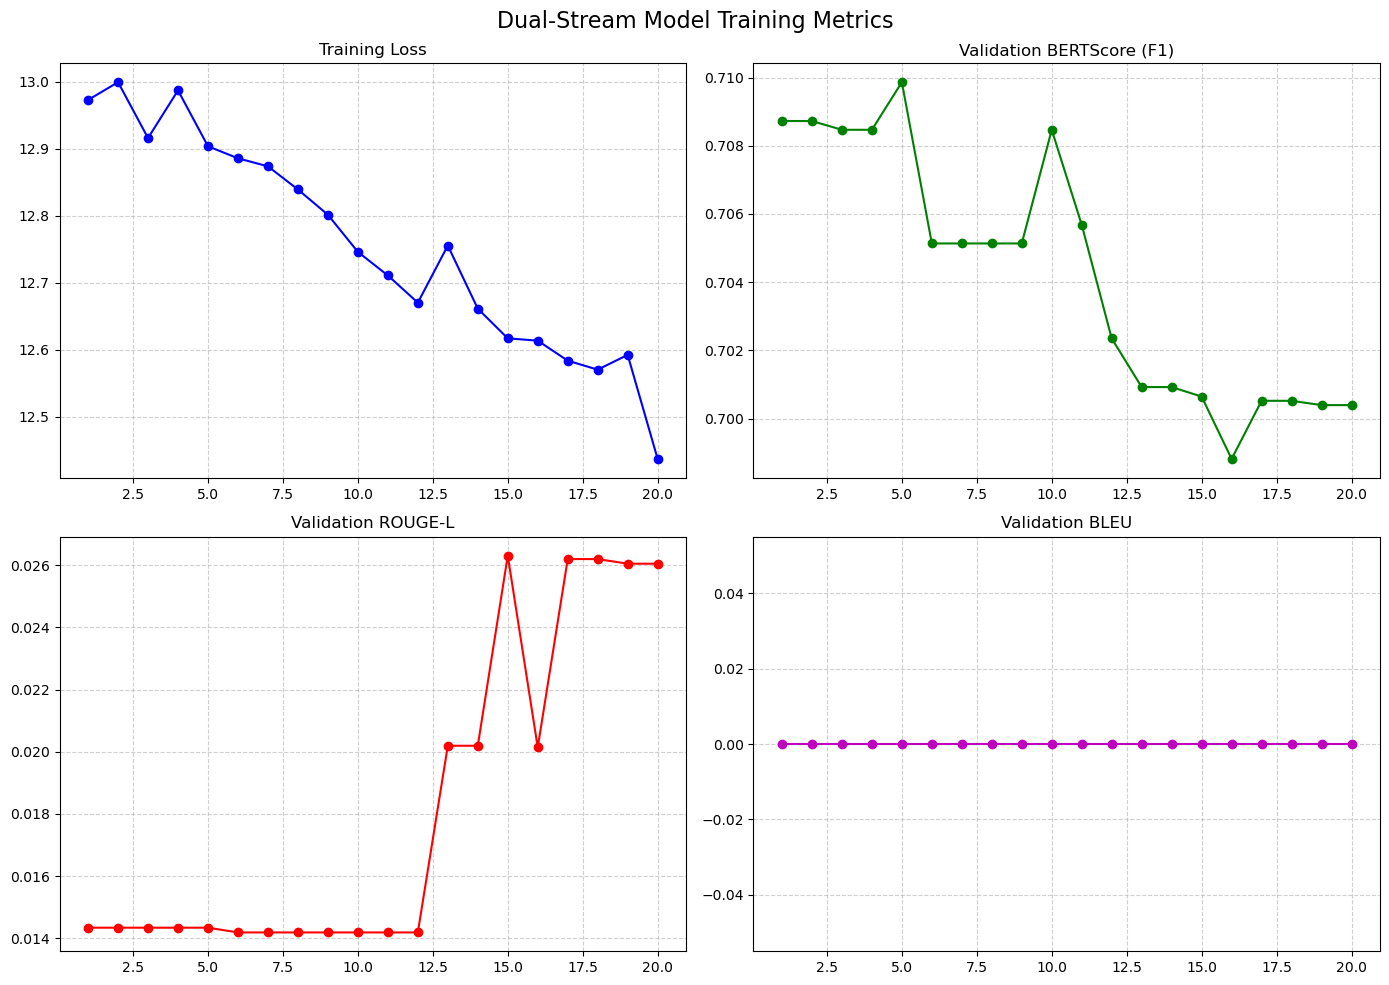

In [5]:
import torch.nn as nn
from torch.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader, random_split
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
import json
import matplotlib.pyplot as plt
from tqdm import tqdm
import evaluate

import torch, gc
gc.collect()
torch.cuda.empty_cache()

LEARNING_RATE = 5e-5

# Options: "gpt2" (124M), "gpt2-medium" (355M), "gpt2-large" (774M), "gpt2-xl" (1.5B)
# Assuming the model download finished successfully
local_folder = "./models/gpt2"

# Pass the LOCAL folder path, not the model name
tokenizer = AutoTokenizer.from_pretrained(local_folder)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",           # High-accuracy 4-bit type
    bnb_4bit_use_double_quant=True,      # Quantize the quantizers for extra space
    bnb_4bit_compute_dtype=torch.float16 # Math still happens in 16-bit
)

base_model = AutoModelForCausalLM.from_pretrained(local_folder, 
                                                #   quantization_config=bnb_config, 
                                                  device_map="auto")
base_model.gradient_checkpointing_enable()
print(f"Base model: {base_model}")

geometric_tokens = [
    # --- Control & Formatting Tokens ---
    # "<GEO_START>", "<GEO_END>", "<DESCRIBE>", "<PAD>",
    "<GEO_START>", "<GEO_END>", "<DESCRIBE>",

    # --- ISO 10303 Topology Tokens (The Graph) ---
    "<VERTEX_POINT>", 
    "<EDGE_CURVE>", "<ORIENTED_EDGE>", 
    "<EDGE_LOOP>", 
    "<FACE_BOUND>", "<FACE_OUTER_BOUND>", "<ADVANCED_FACE>", 
    "<CLOSED_SHELL>", "<OPEN_SHELL>", 
    "<MANIFOLD_SOLID_BREP>",
    
    # --- ISO 10303 Surface Geometry Tokens (The 2D Math) ---
    "<PLANE>", 
    "<CYLINDRICAL_SURFACE>", "<CONICAL_SURFACE>", 
    "<SPHERICAL_SURFACE>", "<TOROIDAL_SURFACE>", 
    "<SURFACE_OF_LINEAR_EXTRUSION>", "<SURFACE_OF_REVOLUTION>", 
    "<B_SPLINE_SURFACE_WITH_KNOTS>", "<RATIONAL_B_SPLINE_SURFACE>",
    
    # --- ISO 10303 Curve Geometry Tokens (The 1D Math) ---
    "<LINE>", "<CIRCLE>", "<ELLIPSE>", 
    "<PARABOLA>", "<HYPERBOLA>", 
    "<B_SPLINE_CURVE_WITH_KNOTS>", "<RATIONAL_B_SPLINE_CURVE>",
    
    # --- ISO 10303 Primitive Math Tokens ---
    "<CARTESIAN_POINT>", "<DIRECTION>", "<VECTOR>", "<AXIS2_PLACEMENT_3D>",

    # --- Macro compressed tokens ---
    "<CYLINDER_PRIMITIVE>", # A CYLINDRICAL_SURFACE node connected to exactly two CIRCLE edge nodes
    "<FILLET_CHAIN>", # Two or more B_SPLINE_SURFACE patches that share a common boundary edge and exhibit C^1 (tangential) continuity
    "<THROUGH_HOLE>", # A CYLINDRICAL_SURFACE where its two bounding CIRCLE edges are each connected to separate, distinct PLANE surfaces with opposing normal vectors.
    "<CHAMFER_EDGE>", #A CONICAL_SURFACE or narrow PLANE that bridges two orthogonal PLANE surfaces, bounded by parallel LINE or CIRCLE edges. 
    "<SPHERE_PRIMITIVE>", # A SPHERICAL_SURFACE bounded by a single CIRCLE edge (forming a hemisphere or ball joint) or a single vertex pole.
    "<PLANAR_PAD>", # A flat PLANE bounded by an EDGE_LOOP, where every edge in the loop connects perpendicularly to a surrounding "skirt" of PLANE or CYLINDRICAL_SURFACE nodes.

    "<ANNOTATE>", # Marker for output
]

num_added_toks = tokenizer.add_special_tokens({'additional_special_tokens': geometric_tokens})

# Ensure there is a padding token
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': '<PAD>'})
    num_added_toks += 1

print(f"Added {num_added_toks} new tokens. New vocab size: {len(tokenizer)} tokens")

# Resize the base model's embedding matrix to accommodate the new tokens
base_model.resize_token_embeddings(len(tokenizer))

# ---------------------------------------------------------
# 1. Dataset Definition
# ---------------------------------------------------------
class CADGeometricDataset(Dataset):
    def __init__(self, jsonl_path, tokenizer, max_length=1024):
        self.data = []
        with open(jsonl_path, "r") as f:
            for line in f:
                if line.strip():
                    self.data.append(json.loads(line))
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        
        # Concatenate the semantic geometry tokens with the Ground Truth annotation
        # The model learns to predict the hierarchical target based on the geometry
        full_text = "".join(item["token_stream"]) + "<ANNOTATE>" + item["hierarchical_target"] + "<|endoftext|>"

        encoding = self.tokenizer(
            full_text,
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt"
        )
        
        # Load Stream B (vectors)
        vectors = torch.tensor(item["vector_stream"], dtype=torch.float32)
        padded_vectors = torch.zeros((self.max_length, 128))
        
        seq_len = min(len(vectors), self.max_length)
        padded_vectors[:seq_len, :] = vectors[:seq_len, :]
        
        input_ids = encoding["input_ids"].squeeze()
        
        return {
            "input_ids": input_ids,
            "attention_mask": encoding["attention_mask"].squeeze(),
            "geometric_vectors": padded_vectors,
            "labels": input_ids.clone() # Causal LM labeling
        }

# ---------------------------------------------------------
# 2. Dual-Stream Model Architecture
# ---------------------------------------------------------
class GeometricSemanticModel(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model 
        # W_p: Projects 128-dim CAD math into 768-dim GPT-2 embedding space
        self.W_p = nn.Linear(128, 768) 
        
    def forward(self, input_ids, geometric_vectors, attention_mask, labels=None):
        # 1. Get standard discrete token embeddings
        inputs_embeds = self.base_model.transformer.wte(input_ids)
        
        # 2. Project Stream B and fuse with Stream A
        geometric_embeds = self.W_p(geometric_vectors)
        fused_embeds = inputs_embeds + geometric_embeds
        
        # 3. Pass through the Transformer
        outputs = self.base_model(
            inputs_embeds=fused_embeds, 
            attention_mask=attention_mask, 
            labels=labels
        )
        return outputs

def annotate(model, tokenizer, start_tokens, prompt_vectors, max_new_tokens=50, device="cuda"):
    model.eval()
    generated_ids = start_tokens.clone()
    
    # Start with the geometric vectors that match the prompt
    current_vectors = prompt_vectors.clone()
    
    with torch.no_grad():
        for _ in range(max_new_tokens):
            if generated_ids.shape[1] >= 1024:
                break

            attn_mask = torch.ones_like(generated_ids).to(device)
            
            outputs = model(
                input_ids=generated_ids, 
                geometric_vectors=current_vectors, 
                attention_mask=attn_mask
            )
            
            # Get the logits for the last predicted token
            next_token_logits = outputs.logits[:, -1, :]
            next_token_id = torch.argmax(next_token_logits, dim=-1).unsqueeze(-1)
            
            # 1. Grow the Text Stream
            generated_ids = torch.cat([generated_ids, next_token_id], dim=-1)
            
            # 2. Grow the Vector Stream (to prevent the 277 vs 276 error!)
            # Assuming 128 is your vector dimension
            zero_vec = torch.zeros((1, 1, 128)).to(device)
            current_vectors = torch.cat([current_vectors, zero_vec], dim=1)
            
            # Stop early if the model predicts <|endoftext|>
            if next_token_id.item() == tokenizer.eos_token_id:
                break
                
    return generated_ids

# ---------------------------------------------------------
# 3. Training Loop & Visualization
# ---------------------------------------------------------
def train():
    global base_model
    global tokenizer
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Initializing training on {device}...")

    if isinstance(base_model, PeftModel) or hasattr(base_model, "peft_config"):
        print("Previous PEFT configuration detected. Unloading old adapters...")
        base_model = base_model.unload()
    
    lora_config = LoraConfig(
        task_type=TaskType.CAUSAL_LM,
        fan_in_fan_out=True,
        r=8,
        lora_alpha=32,
        lora_dropout=0.1,
        target_modules=["c_attn"] # Targeting GPT-2 attention blocks
    )
    base_model = get_peft_model(base_model, lora_config)
    # Wrap in Dual-Stream Architecture
    model = GeometricSemanticModel(base_model).to(device)

    for name, param in model.named_parameters():
        print(f"Layer: {name} | Trainable: {param.requires_grad}")

    # Dataloader
    dataset = CADGeometricDataset("annotated_dataset.jsonl", tokenizer)
    
    metric_bertscore = evaluate.load("bertscore")
    metric_rouge = evaluate.load("rouge")
    metric_bleu = evaluate.load("bleu")

    train_size = int(0.9 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    
    train_dataloader = DataLoader(train_dataset, batch_size=1, shuffle=True)
    # Validation batch size 1 to process generations sequentially without heavy padding
    val_dataloader = DataLoader(val_dataset, batch_size=1, shuffle=False)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    
    epochs = 20
    
    history = {"train_loss": [], "val_bertscore": [], "val_rougeL": [], "val_bleu": []}

    print("Beginning Dual-Stream Fine-Tuning...")

    annotation_token_id = tokenizer.convert_tokens_to_ids("<ANNOTATE>")
    
    # Set up Gradient Accumulation to handle low GPU memory
    accumulation_steps = 16  

    # Initialize the Mixed Precision Scaler
    scaler = GradScaler("cuda")

    for epoch in range(epochs):
        model.train()

        total_loss = 0
        progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        optimizer.zero_grad()
        
        for i, batch in enumerate(progress_bar):
            print(f"i: {i}")
            # Wrap the forward pass in Mixed Precision
            with autocast("cuda", dtype=torch.float16):
                outputs = model(
                    input_ids=batch["input_ids"].to(device),
                    geometric_vectors=batch["geometric_vectors"].to(device),
                    attention_mask=batch["attention_mask"].to(device),
                    labels=batch["labels"].to(device)
                )
                # Scale the loss to account for accumulation
                loss = outputs.loss / accumulation_steps
        
            # Backward pass with scaled gradients
            scaler.scale(loss).backward()
        
            # Only step the optimizer every batchs
            if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_dataloader):
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            
            total_loss += (loss.item() * accumulation_steps)
            progress_bar.set_postfix({"loss": f"{(loss.item() * accumulation_steps):.4f}"})            
        
        avg_train_loss = total_loss / len(train_dataloader)
        history["train_loss"].append(avg_train_loss)
        
        # --- VALIDATION PHASE (Generative Metrics) ---
        val_preds = []
        val_refs = []
        
        # Only validate on a subset (e.g., first 20 items) to save time during epochs
        val_subset_limit = 20 
        
        print(f"Running validation metrics on {val_subset_limit} samples...")
        for i, batch in enumerate(val_dataloader):
            if i >= val_subset_limit: break
            
            input_ids = batch["input_ids"].to(device)
            geom_vectors = batch["geometric_vectors"].to(device)
            
            # Find where <ANNOTATION> occurs to split the prompt from the target
            # In a real batch, you'd extract up to this index
            anno_idx = (input_ids[0] == annotation_token_id).nonzero(as_tuple=True)[0]
            if len(anno_idx) == 0:
                continue
            
            prompt_len = anno_idx[0].item() + 1
            prompt_geom_vectors = geom_vectors[:, :prompt_len, :]
            print(f"prompt_geom_vectors: {prompt_geom_vectors}")

            prompt_ids = input_ids[:, :prompt_len]
            print(f"prompt_ids: {prompt_ids}")
            # Generate the prediction
            generated_ids = annotate(
                model, tokenizer, prompt_ids, prompt_geom_vectors, max_new_tokens=60, device=device
            )
            
            # Isolate just the newly generated text (ignore the topological prompt)
            new_tokens = generated_ids[0][prompt_len:]
            pred_text = tokenizer.decode(new_tokens, skip_special_tokens=True)
            
            # Isolate the ground truth reference
            ref_tokens = input_ids[0][prompt_len:]
            # Filter out padding
            ref_tokens = ref_tokens[ref_tokens != tokenizer.pad_token_id]
            ref_text = tokenizer.decode(ref_tokens, skip_special_tokens=True)

            val_preds.append(pred_text)
            val_refs.append(ref_text)

        print("-------------------------------------------------------------------")
        # Compute Metrics
        print(val_preds)
        print(val_refs)
        print("-------------------------------------------------------------------")

        results_bert = metric_bertscore.compute(
            predictions=val_preds, 
            references=val_refs, 
            lang="en",
            model_type="roberta-base",
            device="cpu"
        )

        results_rouge = metric_rouge.compute(predictions=val_preds, references=val_refs)
        
        # BLEU requires references to be a list of lists
        bleu_refs = [[r] for r in val_refs]
        results_bleu = metric_bleu.compute(predictions=val_preds, references=bleu_refs)
        
        avg_bert = sum(results_bert['f1']) / len(results_bert['f1'])
        
        history["val_bertscore"].append(avg_bert)
        history["val_rougeL"].append(results_rouge['rougeL'])
        history["val_bleu"].append(results_bleu['bleu'])
        
        print("-------------------------------------------------------------------")
        print(f"Epoch {epoch+1} Results: Loss: {avg_train_loss:.4f} | BERTScore: {avg_bert:.4f} | ROUGE-L: {results_rouge['rougeL']:.4f} | BLEU: {results_bleu['bleu']:.4f}")
        print("-------------------------------------------------------------------")

        
    # --- PLOTTING ---
    epochs_range = range(1, epochs + 1)
    
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("Dual-Stream Model Training Metrics", fontsize=16)
    
    axs[0, 0].plot(epochs_range, history["train_loss"], 'b-o')
    axs[0, 0].set_title("Training Loss")
    axs[0, 0].grid(True, linestyle="--", alpha=0.6)
    
    axs[0, 1].plot(epochs_range, history["val_bertscore"], 'g-o')
    axs[0, 1].set_title("Validation BERTScore (F1)")
    axs[0, 1].grid(True, linestyle="--", alpha=0.6)
    
    axs[1, 0].plot(epochs_range, history["val_rougeL"], 'r-o')
    axs[1, 0].set_title("Validation ROUGE-L")
    axs[1, 0].grid(True, linestyle="--", alpha=0.6)
    
    axs[1, 1].plot(epochs_range, history["val_bleu"], 'm-o')
    axs[1, 1].set_title("Validation BLEU")
    axs[1, 1].grid(True, linestyle="--", alpha=0.6)
    
    plt.tight_layout()
    plt.savefig("comprehensive_training_metrics.png", dpi=300)
    print("Metrics plotted and saved to comprehensive_training_metrics.png")

train()

Initializing training on cuda...
3


In [35]:
from torch.utils.data import Dataset
import torch

class CADGeometricDataset(Dataset):
    def __init__(self, jsonl_path, tokenizer, max_length=1024):
        self.data = []
        with open(jsonl_path, "r") as f:
            for line in f:
                self.data.append(json.loads(line))
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        
        # Tokenize the Stream A (text)
        encoding = self.tokenizer(
            item["text_sequence"],
            truncation=True,
            max_length=self.max_length,
            padding="max_length",
            return_tensors="pt"
        )
        
        # Load Stream B (vectors)
        # Pad the vectors to match the max_length of the tokens
        vectors = torch.tensor(item["vector_stream"], dtype=torch.float32)
        padded_vectors = torch.zeros((self.max_length, 128))
        
        # Ensure vectors don't exceed max_length
        seq_len = min(len(vectors), self.max_length)
        padded_vectors[:seq_len, :] = vectors[:seq_len, :]
        
        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "geometric_vectors": padded_vectors,
            "labels": encoding["input_ids"].squeeze() # Standard causal LM labels
        }

In [96]:
class GeometricSemanticModel(torch.nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model # Your fine-tuned GPT-2 with LoRA
        self.W_p = torch.nn.Linear(128, 768) # The 128 -> 768 projection
        
    def forward(self, input_ids, geometric_vectors, attention_mask, labels=None):
        # 1. Get standard word embeddings
        inputs_embeds = self.base_model.transformer.wte(input_ids)
        
        # 2. Project Stream B and add to word embeddings
        geometric_embeds = self.W_p(geometric_vectors)
        fused_embeds = inputs_embeds + geometric_embeds
        
        # 3. Pass through the Transformer
        return self.base_model(inputs_embeds=fused_embeds, attention_mask=attention_mask, labels=labels)

In [ ]:
import torch
import time

def benchmark_inference(model, input_embeddings, max_new_tokens=50):
    # Ensure model is in evaluation mode
    model.eval()
    
    # Create CUDA events for precise timing
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)
    
    # 1. Warm-up run (Crucial!)
    # The first run on a GPU is always slow due to memory initialization. 
    # We run a dummy pass to ensure the GPU is warm.
    with torch.no_grad():
        _ = model.generate(inputs_embeds=input_embeddings, max_new_tokens=10)
    
    # 2. The Actual Benchmark
    torch.cuda.synchronize() # Wait for warm-up to completely finish
    start_event.record()     # Start the stopwatch
    
    with torch.no_grad():
        outputs = model.generate(
            inputs_embeds=input_embeddings, 
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.eos_token_id
        )
        
    end_event.record()       # Stop the stopwatch
    torch.cuda.synchronize() # Wait for GPU to finish generating
    
    # 3. Calculate Metrics
    # elapsed_time returns milliseconds, convert to seconds
    latency_sec = start_event.elapsed_time(end_event) / 1000.0 
    
    # How many tokens did the model actually generate?
    # (outputs shape is usually [batch_size, sequence_length])
    generated_tokens = outputs.shape[1] 
    
    throughput = generated_tokens / latency_sec
    
    print(f"--- Benchmark Results ---")
    print(f"Tokens Generated: {generated_tokens}")
    print(f"Total Latency:    {latency_sec:.4f} seconds")
    print(f"Throughput:       {throughput:.2f} tokens/second")
    
    return outputs

In [ ]:
# Define the local folder where you want to store your finished thesis model
final_save_path = "./models/gpt2-fine-tuned"

print(f"Saving model and tokenizer to {final_save_path}...")

# 1. Save the model's trained LoRA weights and updated embeddings
trainer.model.save_pretrained(final_save_path)

# 2. Save the tokenizer (CRITICAL: This saves your custom <CYLINDER_PRIMITIVE> mapping)
tokenizer.save_pretrained(final_save_path)

print("Save complete! You are ready for offline inference.")